In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("AmesHousing.csv")
print(df.head())
print(df.shape)
print(df.dtypes)

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [3]:
missing_count=df.isnull().sum()
missing_percent=(df.isnull().sum()/len(df)*100).round(2)
missing_table=pd.DataFrame({"missing_count":missing_count,"missing_percent":missing_percent})
missing_table=missing_table.sort_values(ascending=False,by="missing_percent")
missing_table=missing_table[missing_table["missing_percent"]>0]
print(missing_table)
above_20=missing_table[missing_table["missing_percent"]>20]
print("\ncolumn with above 20 % missing values\n")
print(above_20)

numeric_columns=df.select_dtypes(include="number").columns
for col in numeric_columns:
  missing_percent=(df[col].isnull().sum()/len(df)*100).round(2)
  if 0< missing_percent <20:
    median_val=df[col].median()
    df[col]=df[col].fillna(median_val)
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

print("\nRemaining Missing Values\n")
print(remaining_missing)


                missing_count  missing_percent
Pool QC                  2917            99.56
Misc Feature             2824            96.38
Alley                    2732            93.24
Fence                    2358            80.48
Mas Vnr Type             1775            60.58
Fireplace Qu             1422            48.53
Garage Finish             159             5.43
Garage Cond               159             5.43
Garage Qual               159             5.43
Garage Type               157             5.36
Bsmt Exposure              83             2.83
BsmtFin Type 2             81             2.76
Bsmt Cond                  80             2.73
BsmtFin Type 1             80             2.73
Bsmt Qual                  80             2.73
Electrical                  1             0.03

column with above 20 % missing values

              missing_count  missing_percent
Pool QC                2917            99.56
Misc Feature           2824            96.38
Alley                  273

In [4]:
duplicate_count=df.duplicated().sum()
print("Number of duplicated rows: ",duplicate_count)
Before_rows=df.shape[0]
df=df.drop_duplicates()
After_rows=df.shape[0]
print("Number of rows before dropping duplicates: ",Before_rows)
print("Number of rows after dropping duplicates: ",After_rows)
rows_removed=Before_rows-After_rows
print("Number of rows removed: ",rows_removed)
print("\n")
new_missing_percent=(df.isnull().sum()/len(df)*100).round(2)
compare=pd.DataFrame({"Before %": missing_percent,"After %": new_missing_percent})
print(compare)


Number of duplicated rows:  0
Number of rows before dropping duplicates:  2930
Number of rows after dropping duplicates:  2930
Number of rows removed:  0


                Before %  After %
Order                0.0      0.0
PID                  0.0      0.0
MS SubClass          0.0      0.0
MS Zoning            0.0      0.0
Lot Frontage         0.0      0.0
...                  ...      ...
Mo Sold              0.0      0.0
Yr Sold              0.0      0.0
Sale Type            0.0      0.0
Sale Condition       0.0      0.0
SalePrice            0.0      0.0

[82 rows x 2 columns]


In [5]:
display(df.dtypes.to_frame(name="Data Type"))
memory_before=df.memory_usage(deep=True).sum()
print("Memory used before conversion: ",memory_before,"bytes")
df["MS SubClass"]=df["MS SubClass"].astype("category")
df["MS Zoning"]=df["MS Zoning"].astype("category")
print(df[["MS SubClass","MS Zoning"]].dtypes)
memory_after=df.memory_usage(deep=True).sum()
print("Memory used after conversion: ",memory_after,"bytes")

,Data Type
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object


Memory used before conversion:  7251298 bytes
MS SubClass    category
MS Zoning      category
dtype: object
Memory used after conversion:  7085499 bytes


In [6]:
descriptive_stats=df.describe()
print("Descriptive statistics")
display(descriptive_stats)
skewness=df.select_dtypes(include="number").skew()
skewness=skewness.sort_values(ascending=False,key=abs)
most_skewed=skewness.abs().idxmax()
highest_skewnes=skewness[most_skewed]
print("Most Skewned columns are: ",most_skewed)
print("Highest skewness is: ",highest_skewnes)


Descriptive statistics


,Order,PID,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,69.019795,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.096928,442.604778,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,21.326422,7880.017759,1.411026,1.111537,30.245361,20.860286,178.634545,455.515036,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,60.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,162.750000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


Most Skewned columns are:  Misc Val
Highest skewness is:  21.999787616218825


In [7]:
columns=["SalePrice","Lot Area"]
for col in columns:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lowerbound=Q1-(1.5*IQR)
  upperbound=Q3+(1.5*IQR)
  outliers=df[(df[col] < lowerbound) | (df[col] > upperbound)]
  print("Q1: ",Q1)
  print("Q3: ",Q3)
  print("IQR: ",IQR)
  print("Lower Bound: ",lowerbound)
  print("Upper Bound: ",upperbound)
  print("Outliers: ",len(outliers))

Q1:  129500.0
Q3:  213500.0
IQR:  84000.0
Lower Bound:  3500.0
Upper Bound:  339500.0
Outliers:  137
Q1:  7440.25
Q3:  11555.25
IQR:  4115.0
Lower Bound:  1267.75
Upper Bound:  17727.75
Outliers:  127


Line chart


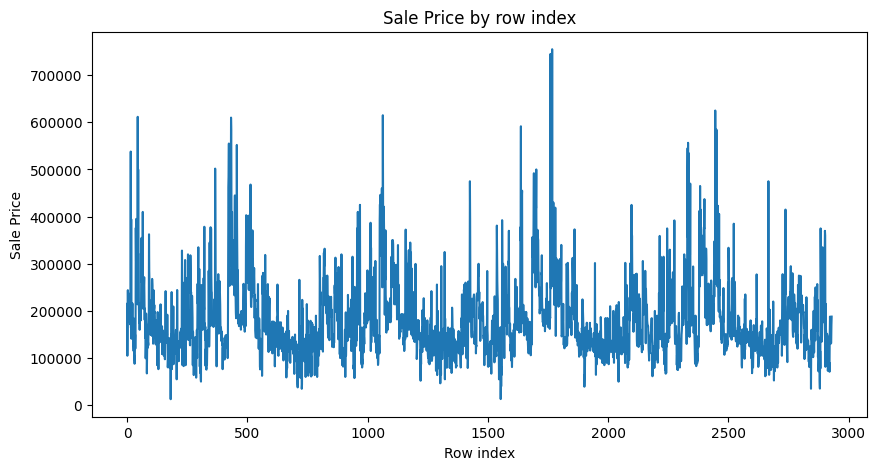


Bar chart


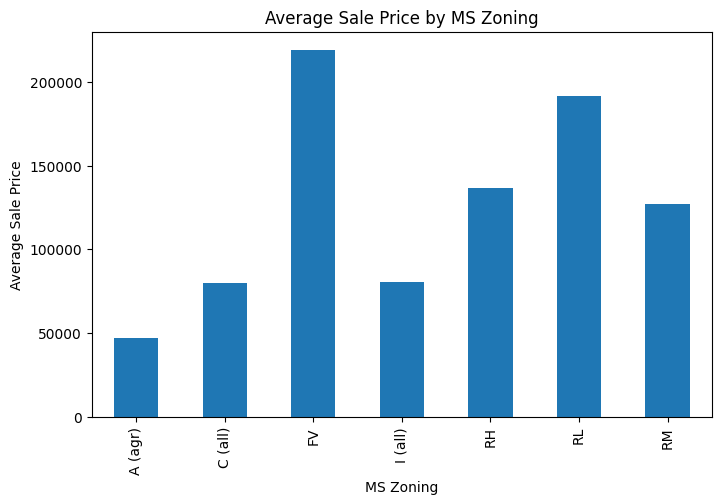


Histogram


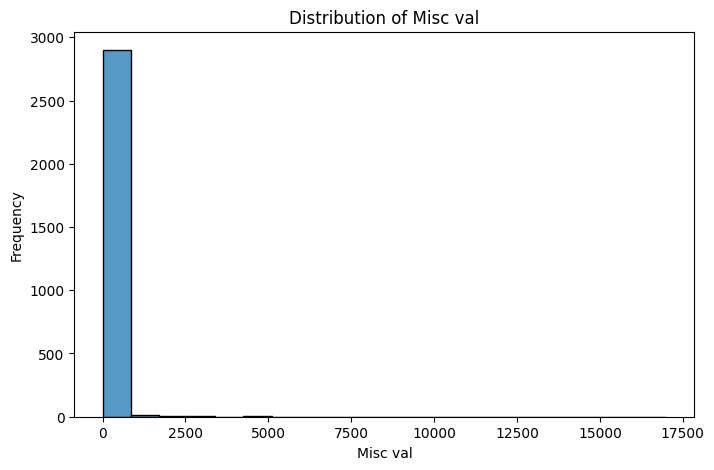


Scatterplot


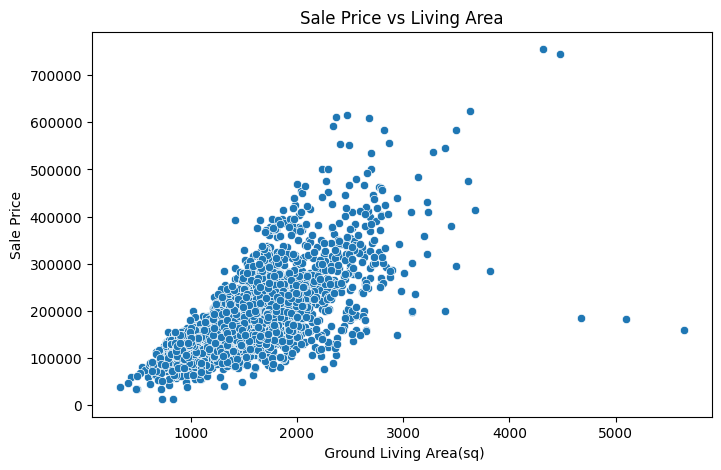


Boxplot


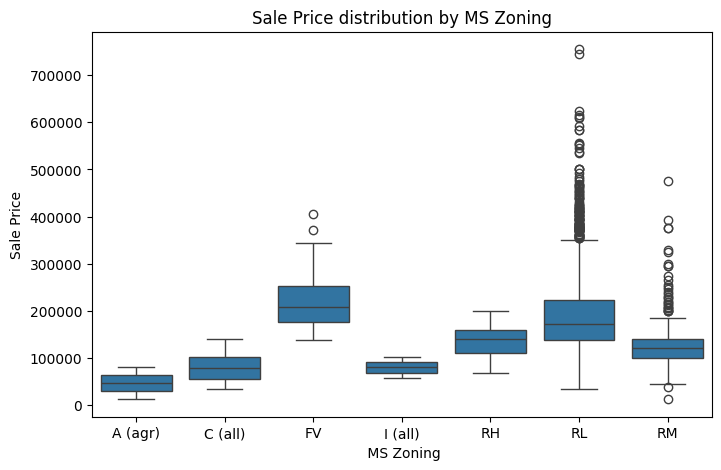

In [8]:
print("Line chart")
plt.figure(figsize=(10,5))
plt.plot(df.index,df["SalePrice"])
plt.title("Sale Price by row index")
plt.xlabel("Row index")
plt.ylabel("Sale Price")
plt.savefig("line_plt.png",dpi=300,bbox_inches="tight")
plt.show()

print("\nBar chart")
plt.figure(figsize=(8,5))
df.groupby("MS Zoning",observed=False)["SalePrice"].mean().plot(kind="bar")
plt.title("Average Sale Price by MS Zoning")
plt.xlabel("MS Zoning")
plt.ylabel("Average Sale Price")
plt.savefig("bar_plt.png",dpi=300,bbox_inches="tight")
plt.show()

print("\nHistogram")
plt.figure(figsize=(8,5))
sns.histplot(df["Misc Val"],bins=20)
plt.title("Distribution of Misc val")
plt.xlabel("Misc val")
plt.ylabel("Frequency")
plt.savefig("hist_plt.png",dpi=300,bbox_inches="tight")
plt.show()

print("\nScatterplot")
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Gr Liv Area",y="SalePrice")
plt.title("Sale Price vs Living Area")
plt.xlabel(" Ground Living Area(sq)")
plt.ylabel("Sale Price")
plt.savefig("scatter_plt.png",dpi=300,bbox_inches="tight")
plt.show()

print("\nBoxplot")
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="MS Zoning",y="SalePrice")
plt.title("Sale Price distribution by MS Zoning")
plt.xlabel(" MS Zoning")
plt.ylabel("Sale Price")
plt.savefig("box_plt.png",dpi=300,bbox_inches="tight")
plt.show()


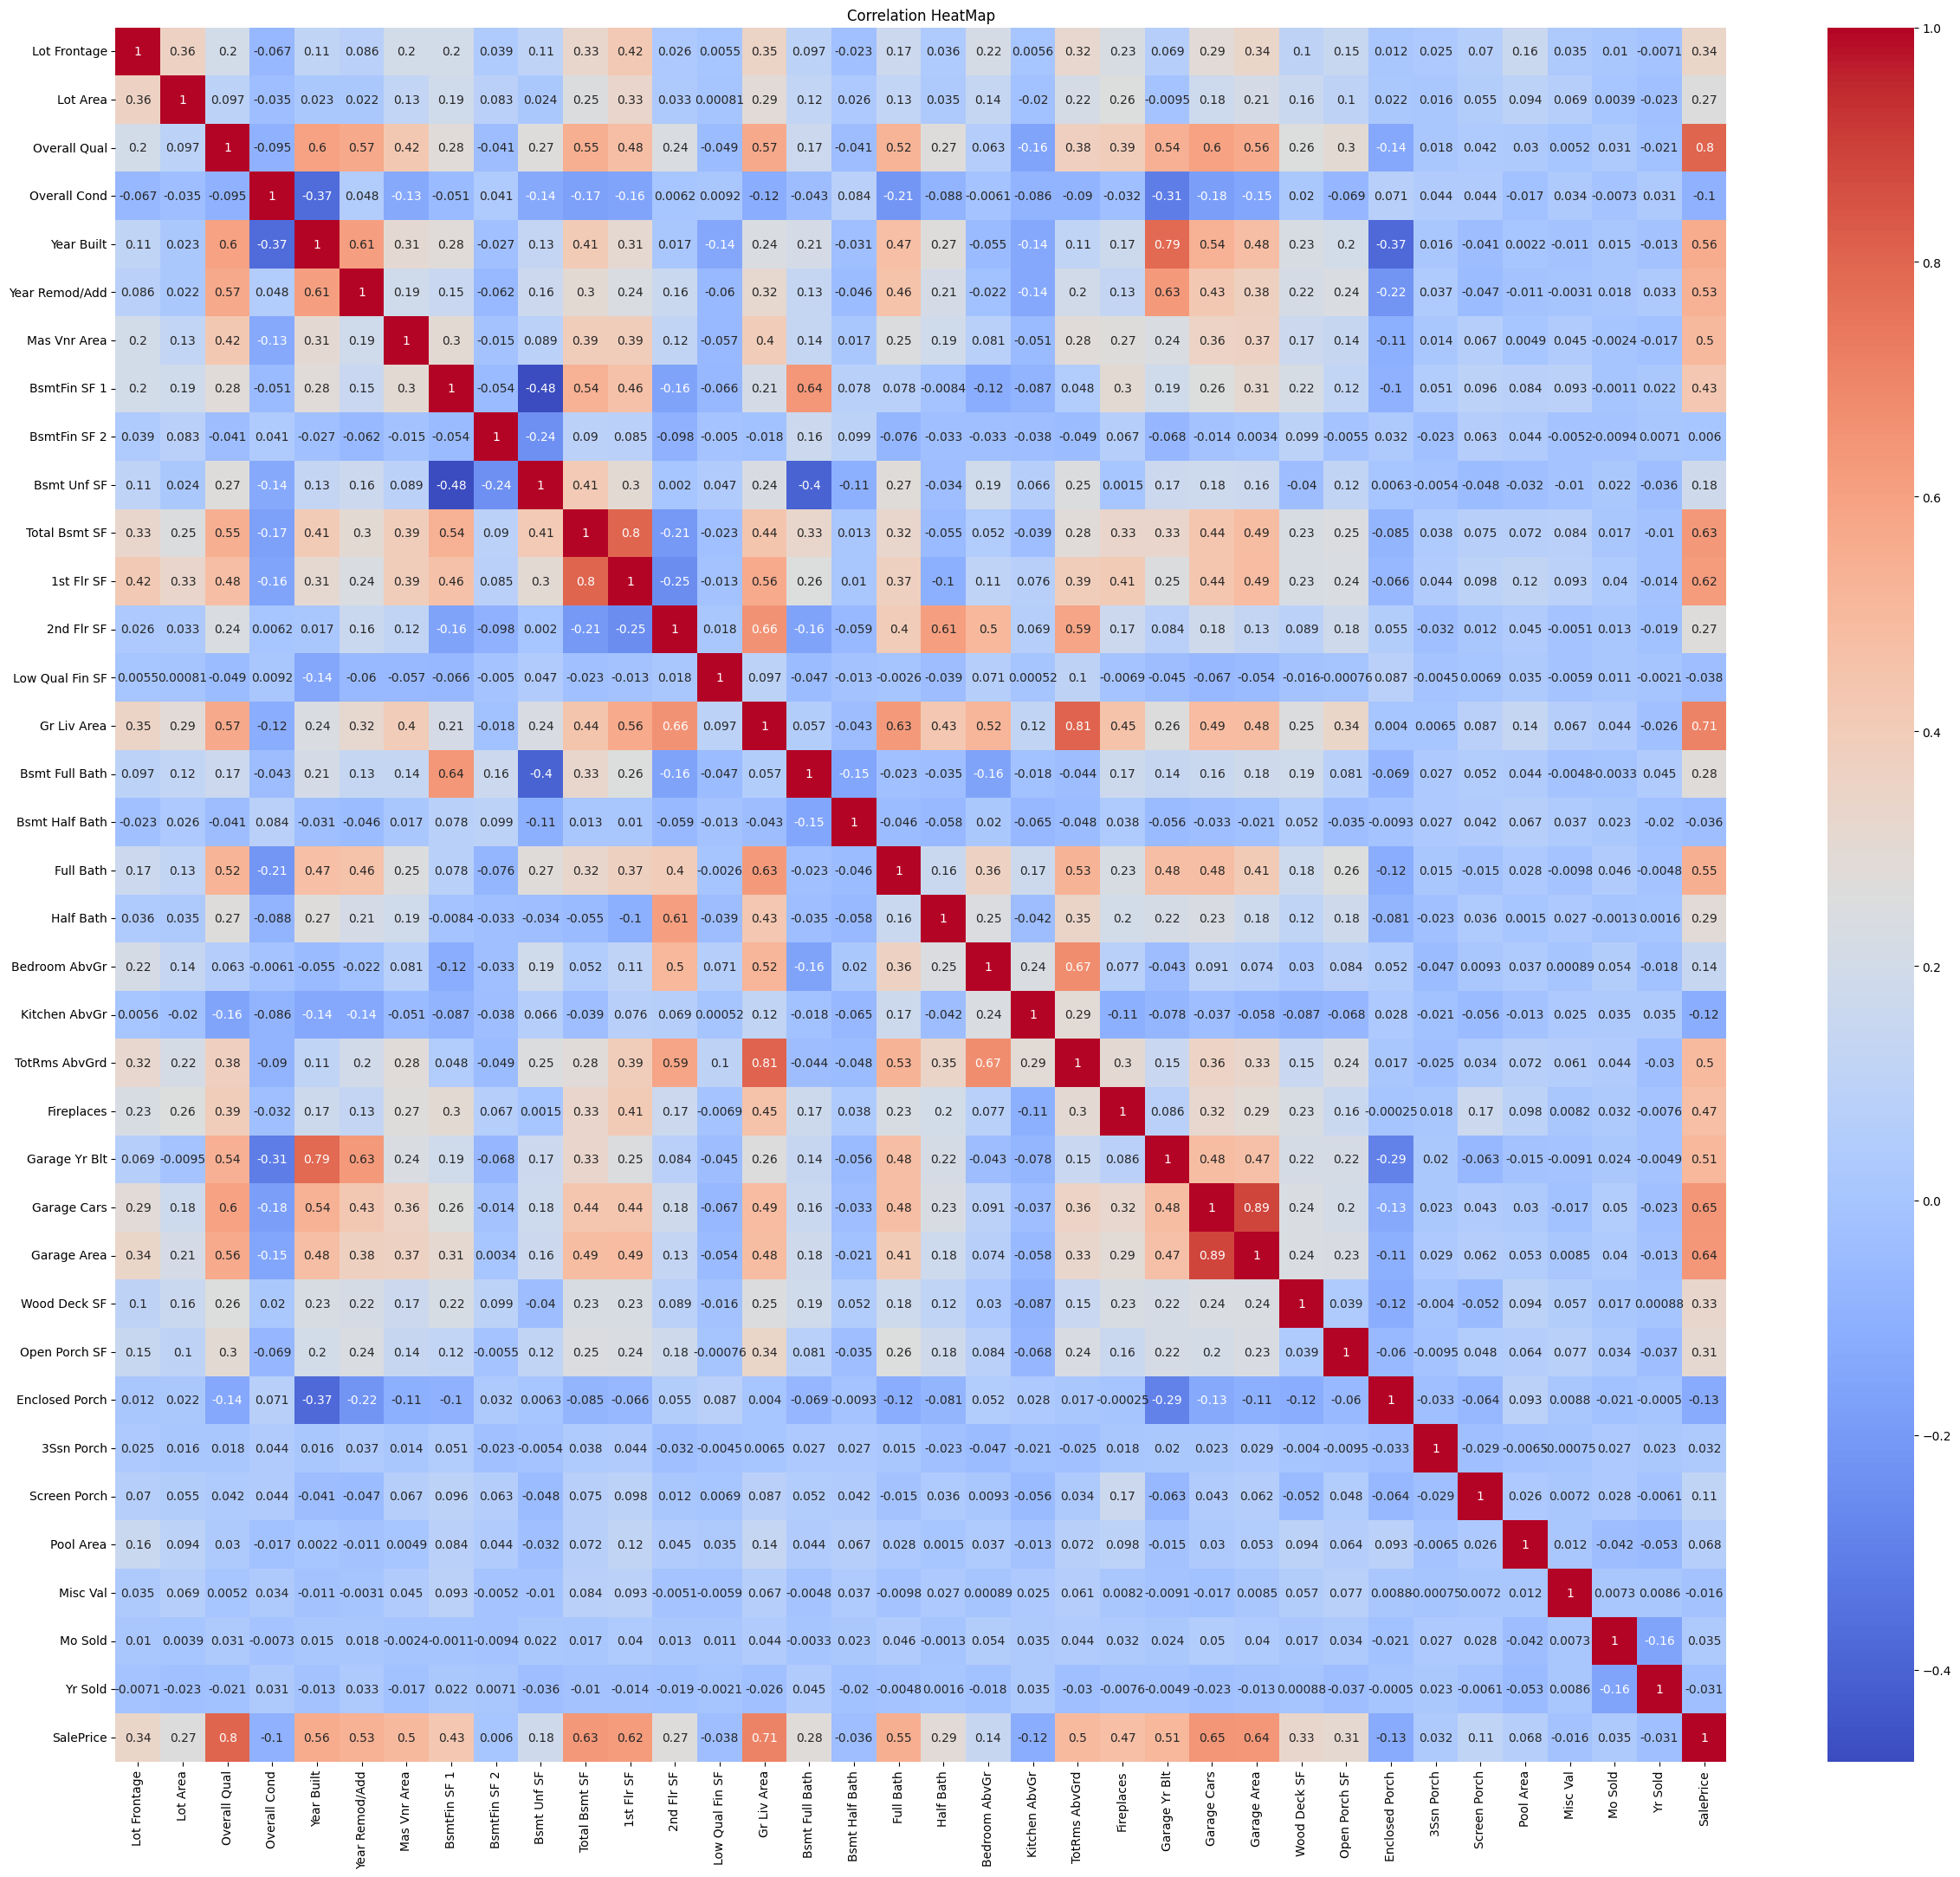

Highest correlation pair:  ('Garage Cars', 'Garage Area')
Highest correlation value:  0.8896653324101758


In [9]:
plt.figure(figsize=(30,26))
numeric_df=df.select_dtypes(include="number").drop(columns=["Order","PID"])
correlation_matrix=numeric_df.corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.savefig("correlation.png",dpi=300,bbox_inches="tight")
plt.show()
matrix=correlation_matrix.abs()
np.fill_diagonal(matrix.values,0)
highest_pair=matrix.stack().idxmax()
highest_value=matrix.stack().max()
print("Highest correlation pair: ",highest_pair)
print("Highest correlation value: ",highest_value)


In [10]:
top2_skewness=skewness.abs().sort_values(ascending=False).head(2).index
print("Top 2 Skewness: ",top2_skewness)
comparison=[]
for col in top2_skewness:
  mean_val=df[col].mean()
  median_val=df[col].median()
  comparison.append({"column":col , "Mean":round(mean_val,2), "Meadian":round(median_val,2), "Skewness":round(skewness[col],2)})
comparison_df=pd.DataFrame(comparison)
print("Mean vs Median")
display(comparison_df)
for col in top2_skewness:
  df[col]=df[col].fillna(df[col].median())
print("Remaining Null values")
print(df[top2_skewness].isnull().sum())

Top 2 Skewness:  Index(['Misc Val', 'Pool Area'], dtype='object')
Mean vs Median


,column,Mean,Meadian,Skewness
0,Misc Val,50.64,0.0,22.00
1,Pool Area,2.24,0.0,16.94


Remaining Null values
Misc Val     0
Pool Area    0
dtype: int64


In [11]:
numeric_df=df.select_dtypes(include="number").drop(columns=["Order","PID"])
correlation_matrix=numeric_df.corr()
spearman_corr=numeric_df.corr(method="spearman")
print("correlation matrix")
display(correlation_matrix)
print("spearman correlation matrix")
display(spearman_corr)
difference=(spearman_corr - correlation_matrix).abs()
pairs=[]
for i in range(len(difference.columns)):
  for j in range(i+1, len(difference.columns)):
    pairs.append({"Column 1":difference.columns[i], "Column 2":difference.columns[j], "Spearman Correlation":spearman_corr.iloc[i,j], "Correlation":correlation_matrix.iloc[i,j], "Difference":difference.iloc[i,j]})
difference_table=pd.DataFrame(pairs)
difference_table=difference_table.sort_values(by="Difference",ascending=False)
print("Top 3 Largest Differences")
display(difference_table.head(3))

correlation matrix


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Lot Frontage,1.000000,0.362758,0.198917,-0.067140,0.114341,0.086139,0.201685,0.198161,0.039157,0.109586,...,0.102790,0.150107,0.012165,0.025157,0.070101,0.160860,0.035368,0.010477,-0.007123,0.340256
Lot Area,0.362758,1.000000,0.097188,-0.034759,0.023258,0.021682,0.125950,0.191574,0.083198,0.023696,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549
Overall Qual,0.198917,0.097188,1.000000,-0.094812,0.597027,0.569609,0.423089,0.284091,-0.041122,0.270062,...,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,0.005179,0.031103,-0.020719,0.799262
Overall Cond,-0.067140,-0.034759,-0.094812,1.000000,-0.368773,0.047680,-0.132472,-0.050991,0.040992,-0.136872,...,0.020344,-0.068934,0.071459,0.043852,0.044055,-0.016787,0.034056,-0.007295,0.031207,-0.101697
Year Built,0.114341,0.023258,0.597027,-0.368773,1.000000,0.612095,0.306797,0.279881,-0.027328,0.129042,...,0.228964,0.198365,-0.374364,0.015803,-0.041436,0.002213,-0.011011,0.014577,-0.013197,0.558426
Year Remod/Add,0.086139,0.021682,0.569609,0.047680,0.612095,1.000000,0.191740,0.151809,-0.061934,0.164847,...,0.217857,0.241748,-0.220383,0.037412,-0.046888,-0.011410,-0.003132,0.018048,0.032652,0.532974
Mas Vnr Area,0.201685,0.125950,0.423089,-0.132472,0.306797,0.191740,1.000000,0.299841,-0.014955,0.089481,...,0.165875,0.140003,-0.109915,0.014222,0.066817,0.004893,0.045276,-0.002358,-0.016876,0.502196
BsmtFin SF 1,0.198161,0.191574,0.284091,-0.050991,0.279881,0.151809,0.299841,1.000000,-0.054112,-0.477857,...,0.224028,0.124974,-0.100433,0.050546,0.095888,0.084143,0.092890,-0.001110,0.022389,0.432862
BsmtFin SF 2,0.039157,0.083198,-0.041122,0.040992,-0.027328,-0.061934,-0.014955,-0.054112,1.000000,-0.238590,...,0.098591,-0.005516,0.032415,-0.023314,0.062978,0.044403,-0.005195,-0.009401,0.007089,0.006018
Bsmt Unf SF,0.109586,0.023696,0.270062,-0.136872,0.129042,0.164847,0.089481,-0.477857,-0.238590,1.000000,...,-0.039564,0.118920,0.006255,-0.005438,-0.048061,-0.031994,-0.010160,0.021625,-0.036395,0.182895


spearman correlation matrix


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Lot Frontage,1.000000,0.573014,0.207339,-0.098224,0.185710,0.120682,0.255081,0.156450,0.044132,0.075815,...,0.109976,0.159865,-0.097697,0.009730,0.079372,0.078772,0.034338,0.007870,0.000969,0.370670
Lot Area,0.573014,1.000000,0.196855,-0.079006,0.121151,0.103266,0.203267,0.171297,0.057608,0.068198,...,0.177609,0.171777,-0.042467,0.029028,0.091527,0.083071,0.073861,0.004774,-0.021720,0.429249
Overall Qual,0.207339,0.196855,1.000000,-0.189638,0.664590,0.579323,0.414913,0.179159,-0.091639,0.239132,...,0.290231,0.440433,-0.192093,0.019398,0.026212,0.033057,-0.076443,0.029163,-0.017015,0.808800
Overall Cond,-0.098224,-0.079006,-0.189638,1.000000,-0.422306,-0.075119,-0.177249,-0.020646,0.095735,-0.123354,...,-0.036363,-0.175446,0.134745,0.044303,0.050333,-0.020386,0.061434,-0.006480,0.039612,-0.165657
Year Built,0.185710,0.121151,0.664590,-0.422306,1.000000,0.707678,0.388014,0.214540,-0.095415,0.124278,...,0.296569,0.402890,-0.434250,0.011180,-0.066507,0.004203,-0.079103,0.016111,-0.009527,0.680822
Year Remod/Add,0.120682,0.103266,0.579323,-0.075119,0.707678,1.000000,0.240754,0.087744,-0.116493,0.166915,...,0.249966,0.372293,-0.268871,0.049288,-0.058677,-0.011139,-0.057701,0.014296,0.041084,0.601454
Mas Vnr Area,0.255081,0.203267,0.414913,-0.177249,0.388014,0.240754,1.000000,0.268895,-0.026987,0.052800,...,0.185712,0.213622,-0.186199,0.025765,0.059830,0.001738,-0.039001,0.009129,-0.007162,0.434773
BsmtFin SF 1,0.156450,0.171297,0.179159,-0.020646,0.214540,0.087744,0.268895,1.000000,0.057946,-0.546771,...,0.208274,0.094946,-0.146952,0.060471,0.092409,0.030037,0.019956,-0.006601,0.025814,0.331962
BsmtFin SF 2,0.044132,0.057608,-0.091639,0.095735,-0.095415,-0.116493,-0.026987,0.057946,1.000000,-0.298051,...,0.060636,-0.056353,0.027614,0.000716,0.058630,0.054816,0.035818,-0.010675,0.021326,-0.033861
Bsmt Unf SF,0.075815,0.068198,0.239132,-0.123354,0.124278,0.166915,0.052800,-0.546771,-0.298051,1.000000,...,-0.047220,0.146339,0.036076,-0.013715,-0.047368,-0.036492,-0.058443,0.022707,-0.036381,0.163236


Top 3 Largest Differences


,Column 1,Column 2,Spearman Correlation,Correlation,Difference
0,Lot Frontage,Lot Area,0.573014,0.362758,0.210256
156,Year Built,Open Porch SF,0.402890,0.198365,0.204525
555,Garage Yr Blt,Open Porch SF,0.393550,0.220065,0.173485


In [12]:
group_stats=df.groupby("MS Zoning",observed=False)["SalePrice"].agg(["mean","std","count"])
print(group_stats)
highest_mean_group=group_stats["mean"].idxmax()
highest_std_group=group_stats["std"].idxmax()
highest_mean=group_stats["mean"].max()
lowest_mean=group_stats["mean"].min()
ratio=highest_mean / lowest_mean
print("group of highest mean: ",highest_mean_group)
print("group with highest standard deviation: ",highest_std_group)
print("highest_mean / lowest_mean ratio: ",round(ratio,2))

                    mean           std  count
MS Zoning                                    
A (agr)     47300.000000  48366.103833      2
C (all)     79795.040000  31084.817206     25
FV         218986.949640  52684.229037    139
I (all)     80312.500000  32084.970196      2
RH         136419.777778  36173.101244     27
RL         191283.251650  81295.736203   2273
RM         126781.393939  48145.542821    462
group of highest mean:  FV
group with highest standard deviation:  RL
highest_mean / lowest_mean ratio:  4.63


In [13]:
df.to_csv("cleaned_data.csv",index=False)
print("cleaned_data.csv saved successfully.")

cleaned_data.csv saved successfully.


In [14]:
df_ml=df.copy()
columns_to_drop=["Pool QC","Misc Feature","Alley","Fence","Mas Vnr Type","Fireplace Qu"]
df_ml=df_ml.drop(columns=columns_to_drop)
categorical_cols=df_ml.select_dtypes(include=["object","category"]).columns
for col in categorical_cols:
  if df_ml[col].isnull().sum() > 0:
    df_ml[col]=df_ml[col].fillna(df_ml[col].mode()[0])
print("Total missing values:",df_ml.isnull().sum().sum())
df_ml.to_csv("cleaned_data.csv",index=False)
print("Ml ready cleaned_data.csv saved successfully!")

Total missing values: 0
Ml ready cleaned_data.csv saved successfully!
